In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

df = pd.read_csv('Dataset/credit_risk_dataset.csv', sep=';')
df = df[df['person_age'] <= 90]
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['log_person_income'] = np.log1p(df['person_income'])

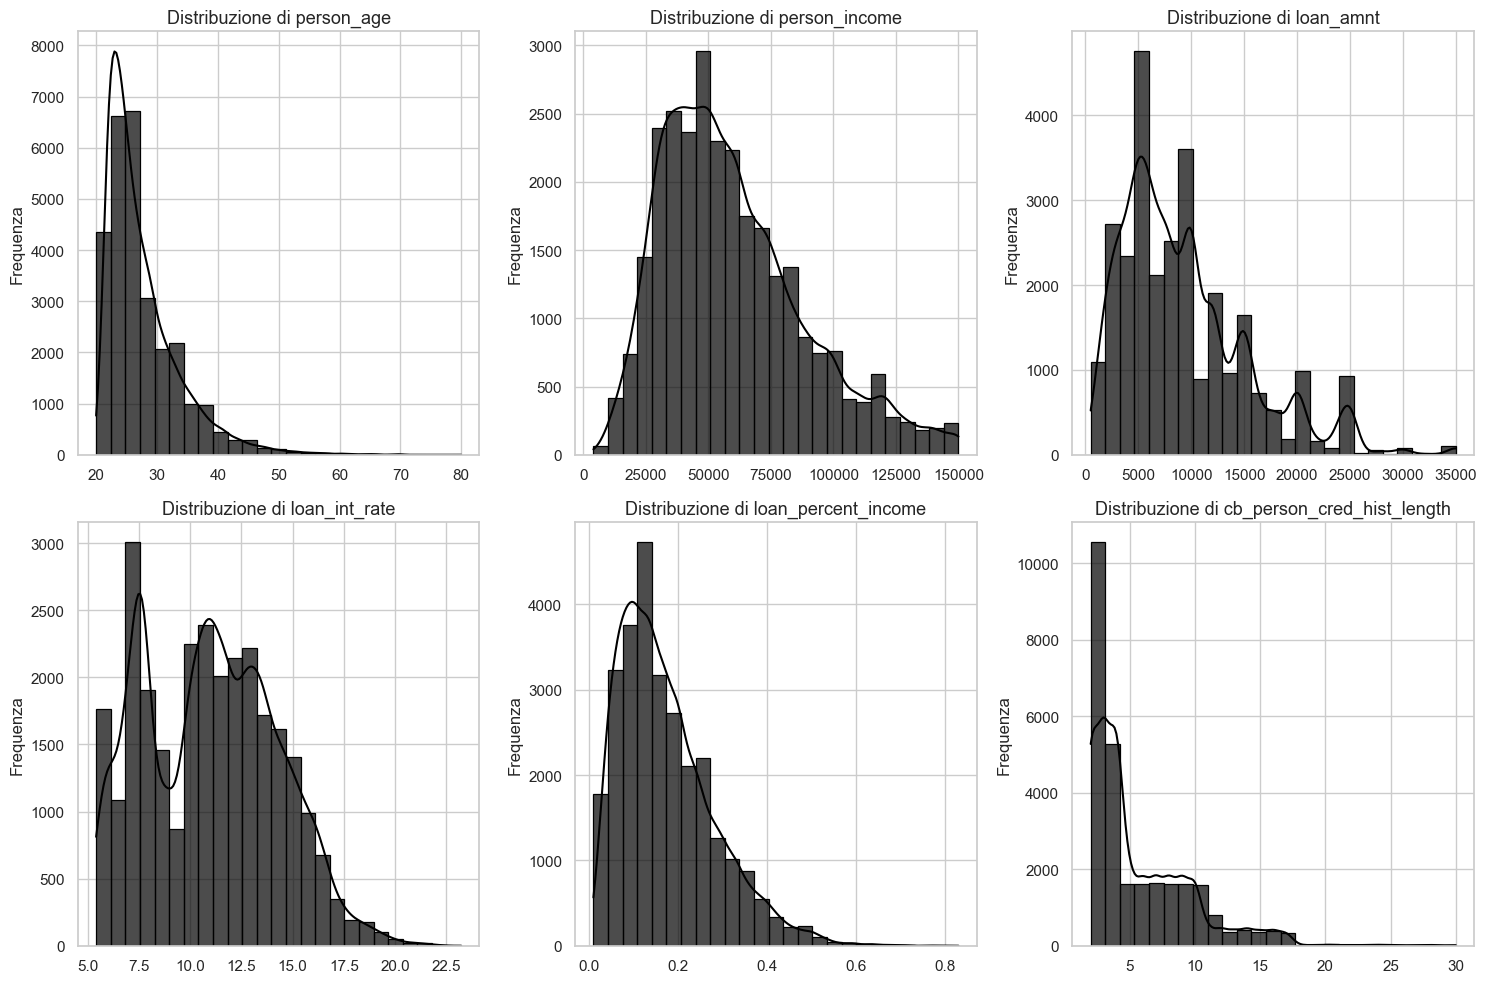

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtriamo i dati (fondamentale se non usiamo il logaritmo)
# Rimuoviamo età estreme e redditi sopra i 150.000$ per rendere il grafico leggibile
df_clean = df[(df['person_age'] <= 80) & (df['person_income'] <= 150000)].copy()

# 2. Selezioniamo SOLO le variabili numeriche originali (niente logaritmo)
num_cols = ['person_age', 'person_income', 'loan_amnt', 
            'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

# 3. Creiamo la griglia (2 righe, 3 colonne è perfetta per 6 variabili)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Usiamo bins=25 per "compattare" le barre ed evitare i buchi vuoti. 
    # Manteniamo il KDE (la linea), che ora si adatterà molto meglio.
    sns.histplot(df_clean[col], bins=25, kde=True, ax=axes[i], color='black', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribuzione di {col}', fontsize=13)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequenza')

plt.tight_layout()
plt.show()

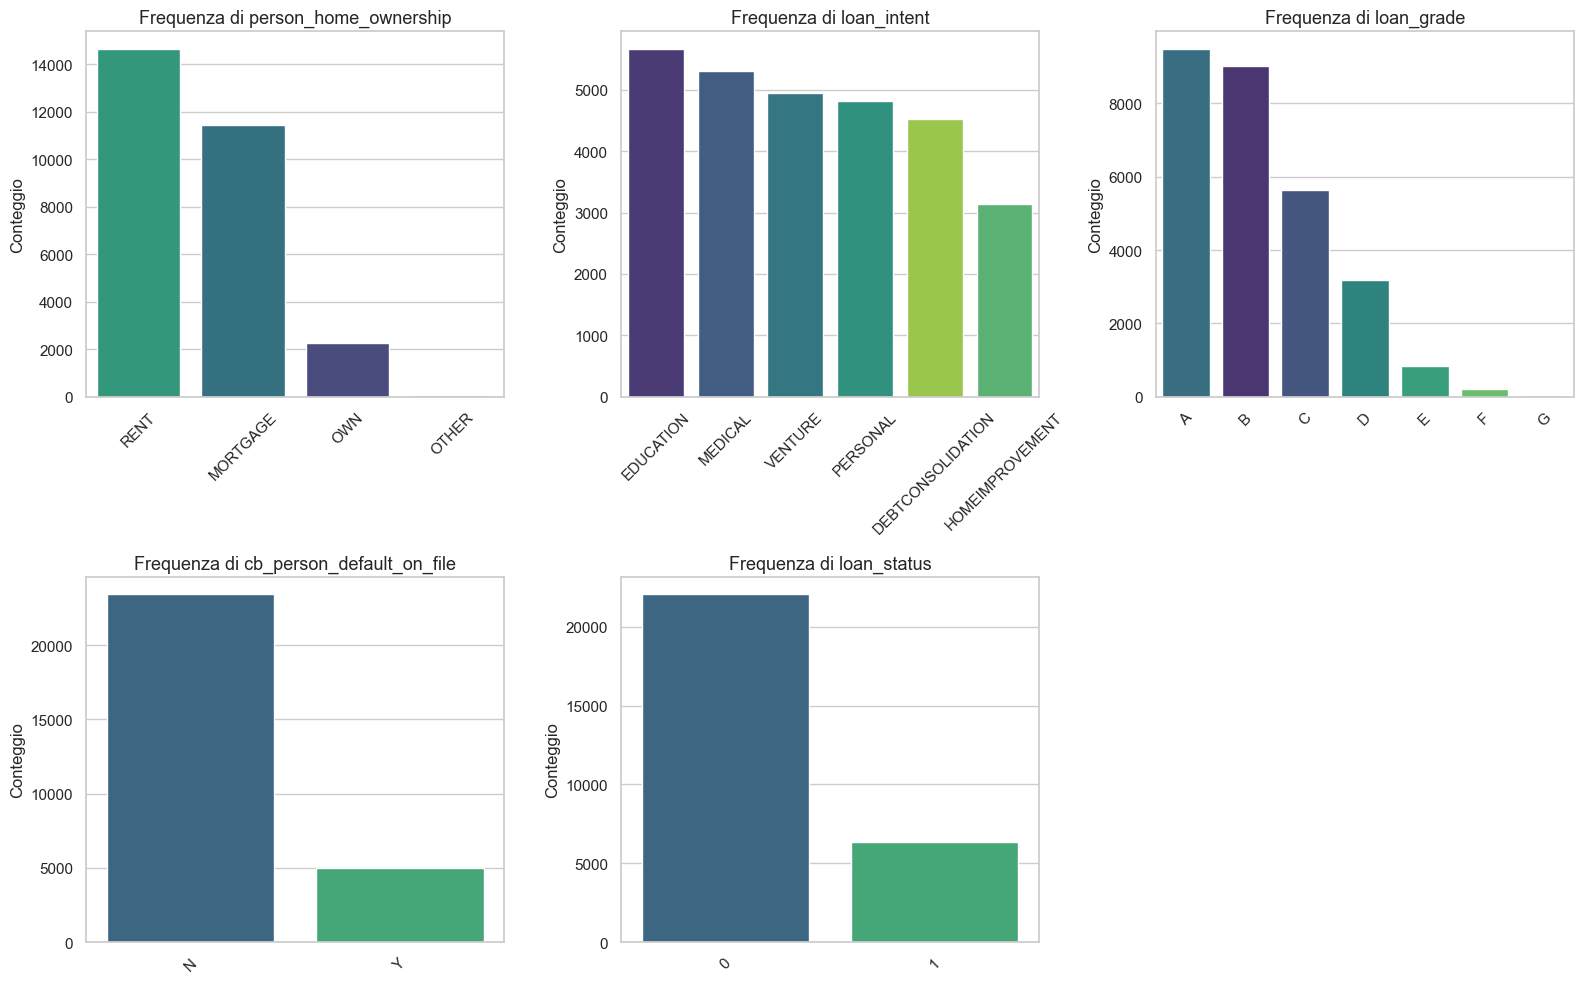

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assicuriamoci di usare il dataset pulito (df_clean)
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file', 'loan_status']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):

    if col == 'loan_grade':
        ordine = sorted(df_clean[col].dropna().unique())
    else:
        ordine = df_clean[col].value_counts().index
        
    sns.countplot(x=col, data=df_clean, ax=axes[i], palette='viridis', 
                  order=ordine, hue=col, legend=False)
    
    axes[i].set_title(f'Frequenza di {col}', fontsize=13)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Conteggio')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

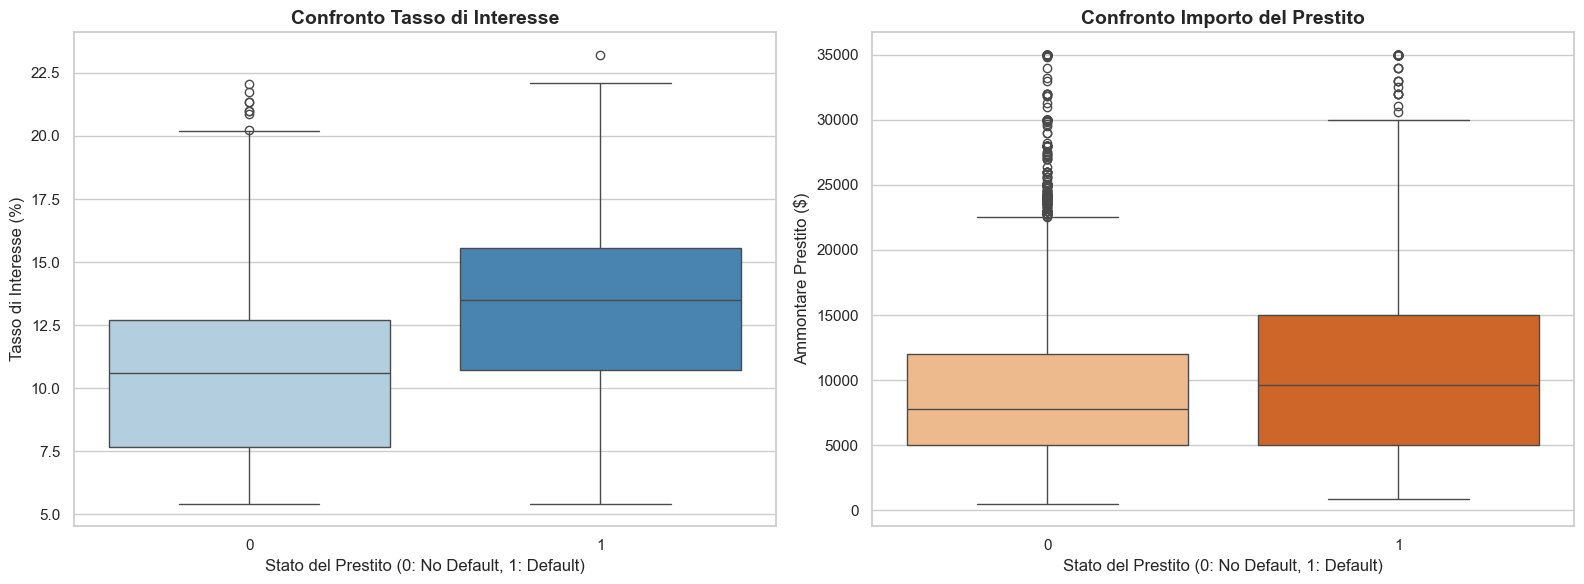

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.boxplot(x='loan_status', y='loan_int_rate', data=df_clean, 
            palette='Blues', ax=axes[0], hue='loan_status', legend=False)
axes[0].set_title('Confronto Tasso di Interesse', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Stato del Prestito (0: No Default, 1: Default)')
axes[0].set_ylabel('Tasso di Interesse (%)')

sns.boxplot(x='loan_status', y='loan_amnt', data=df_clean, 
            palette='Oranges', ax=axes[1], hue='loan_status', legend=False)
axes[1].set_title('Confronto Importo del Prestito', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Stato del Prestito (0: No Default, 1: Default)')
axes[1].set_ylabel('Ammontare Prestito ($)')

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
from scipy import stats


num_cols = ['person_age', 'person_income', 'loan_amnt', 
            'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

risultati_ks = []

for col in num_cols:

    data = df_clean[col].dropna()
    

    data_z = (data - data.mean()) / data.std()

    stat, p_value = stats.kstest(data_z, 'norm')

    risultati_ks.append({
        'Variabile': col,
        'Statistica KS (D)': round(stat, 4),
        'P-Value': "< 0.001" if p_value < 0.001 else round(p_value, 4),
        'Distribuzione Normale?': 'No' if p_value < 0.05 else 'Sì'
    })


tabella_ks = pd.DataFrame(risultati_ks)
print("=== TABELLA TEST DI KOLMOGOROV-SMIRNOV ===")
display(tabella_ks)

=== TABELLA TEST DI KOLMOGOROV-SMIRNOV ===


,Variabile,Statistica KS (D),P-Value,Distribuzione Normale?
0,person_age,0.1608,< 0.001,No
1,person_income,0.0910,< 0.001,No
2,loan_amnt,0.1300,< 0.001,No
3,loan_int_rate,0.0957,< 0.001,No
4,loan_percent_income,0.1001,< 0.001,No
5,cb_person_cred_hist_length,0.2239,< 0.001,No


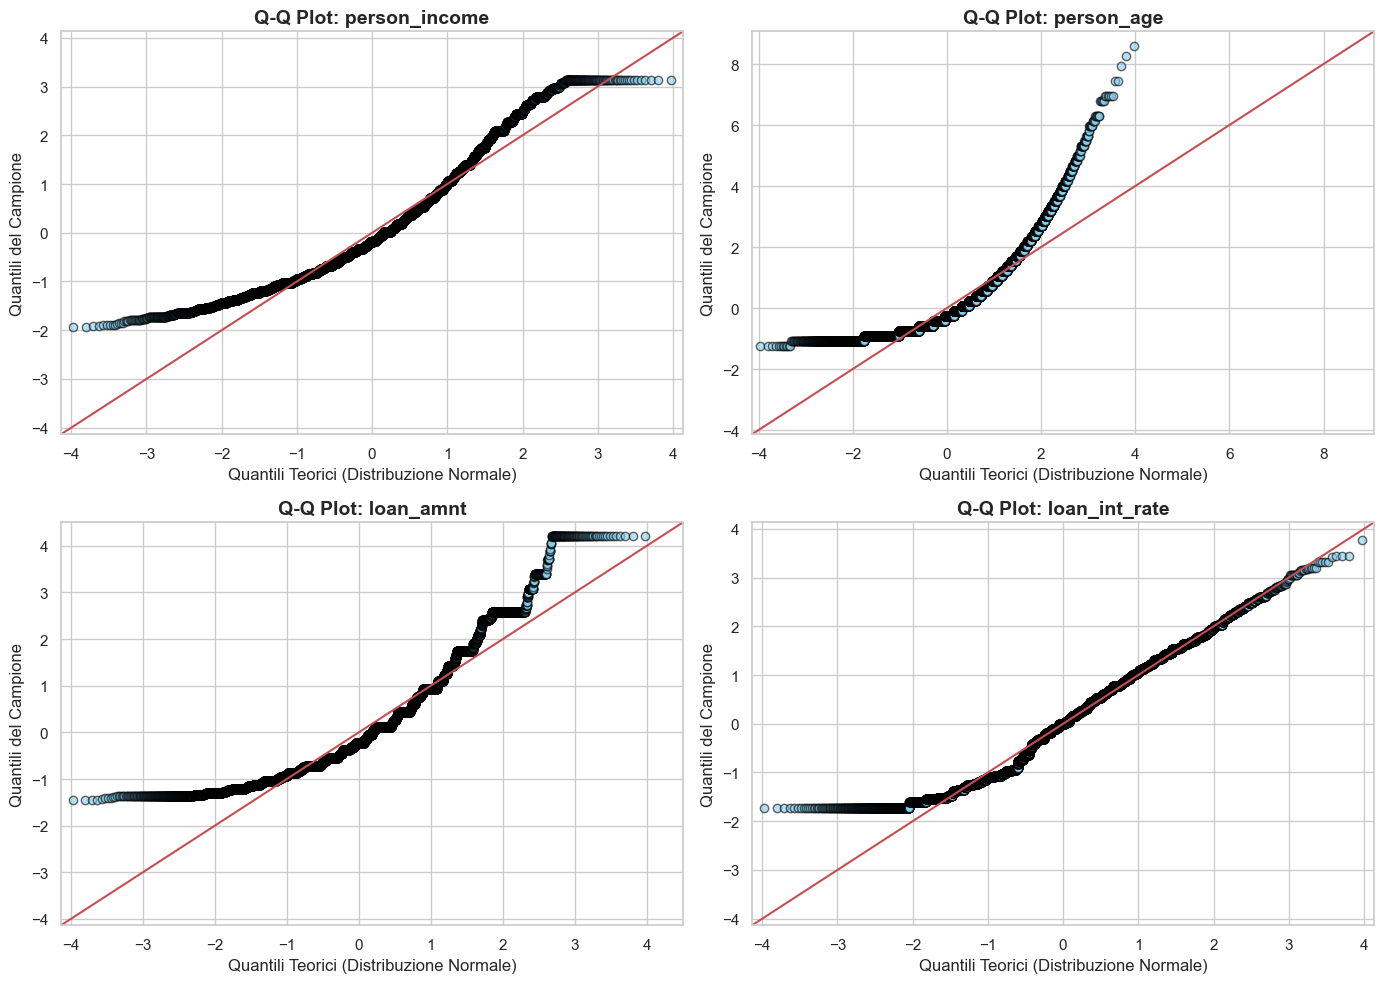

In [7]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats


variabili_qq = ['person_income', 'person_age', 'loan_amnt', 'loan_int_rate']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(variabili_qq):

    dati = df_clean[col].dropna()
    

    sm.qqplot(dati, dist=stats.norm, fit=True, line='45', ax=axes[i], 
              markerfacecolor='skyblue', markeredgecolor='black', alpha=0.6)
    
    axes[i].set_title(f'Q-Q Plot: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Quantili Teorici (Distribuzione Normale)')
    axes[i].set_ylabel('Quantili del Campione')

plt.tight_layout()
plt.show()

In [8]:
import statsmodels.api as sm
from statsmodels.formula.api import ols


modello_anova = ols('loan_amnt ~ loan_intent', data=df_clean).fit()
tabella_anova = sm.stats.anova_lm(modello_anova, typ=2)

print("=== RISULTATI TEST ANOVA (Importo vs Finalità) ===")
display(tabella_anova)

p_val = tabella_anova.loc['loan_intent', 'PR(>F)']

if p_val < 0.05:
    print(f"\nInterpretazione: Il p-value ({p_val:.4e}) è inferiore a 0.05.")
    print("Rifiutiamo H0: La finalità del prestito influenza significativamente l'importo richiesto.")
else:
    print("\nInterpretazione: Non c'è evidenza statistica che la finalità influenzi l'importo.")

=== RISULTATI TEST ANOVA (Importo vs Finalità) ===


,sum_sq,df,F,PR(>F)
loan_intent,1.645431e+09,5.0,8.915435,1.795486e-08
Residual,1.049038e+12,28420.0,NaN,NaN



Interpretazione: Il p-value (1.7955e-08) è inferiore a 0.05.
Rifiutiamo H0: La finalità del prestito influenza significativamente l'importo richiesto.


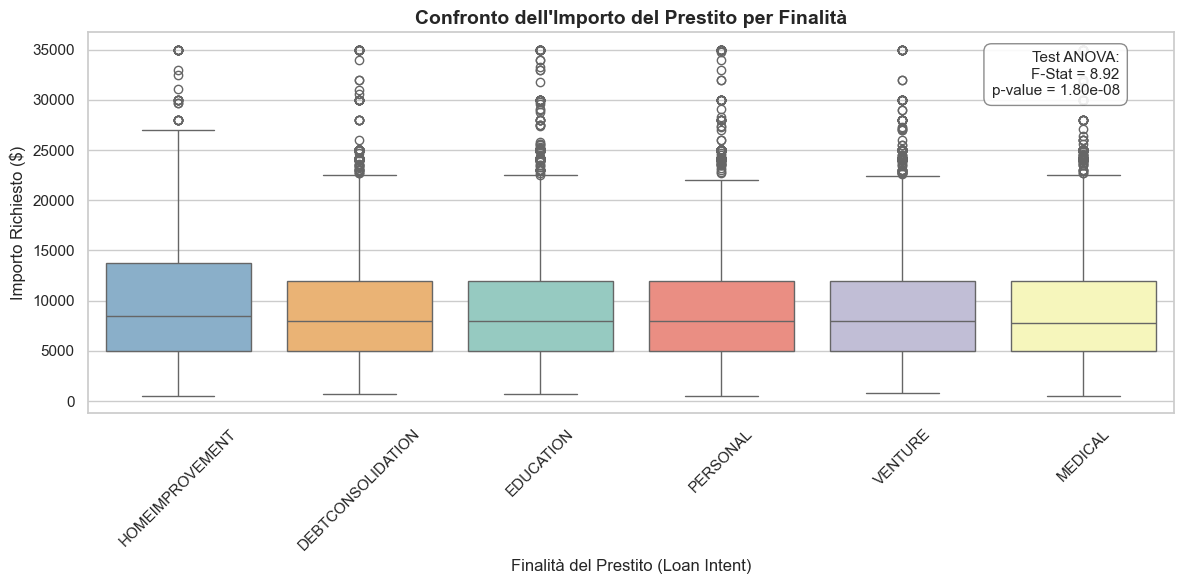

In [9]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns


modello_anova = ols('loan_amnt ~ loan_intent', data=df_clean).fit()
tabella_anova = sm.stats.anova_lm(modello_anova, typ=2)


f_stat = tabella_anova.loc['loan_intent', 'F']
p_val = tabella_anova.loc['loan_intent', 'PR(>F)']


plt.figure(figsize=(12, 6))


ordine_categorie = df_clean.groupby('loan_intent')['loan_amnt'].median().sort_values(ascending=False).index

ax = sns.boxplot(x='loan_intent', y='loan_amnt', data=df_clean, 
                 order=ordine_categorie, palette='Set3', hue='loan_intent', legend=False)


stats_text = (f"Test ANOVA:\n"
              f"F-Stat = {f_stat:.2f}\n"
              f"p-value = {p_val:.2e}")


props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray')


ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right', bbox=props)


plt.title("Confronto dell'Importo del Prestito per Finalità", fontsize=14, fontweight='bold')
plt.xlabel("Finalità del Prestito (Loan Intent)", fontsize=12)
plt.ylabel("Importo Richiesto ($)", fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

C:\Users\AndreaRiccobene\AppData\Local\Temp\ipykernel_24556\302394339.py:17: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  tabella_perc = tabella_contingenza.div(tabella_contingenza.sum(1), axis=0) * 100


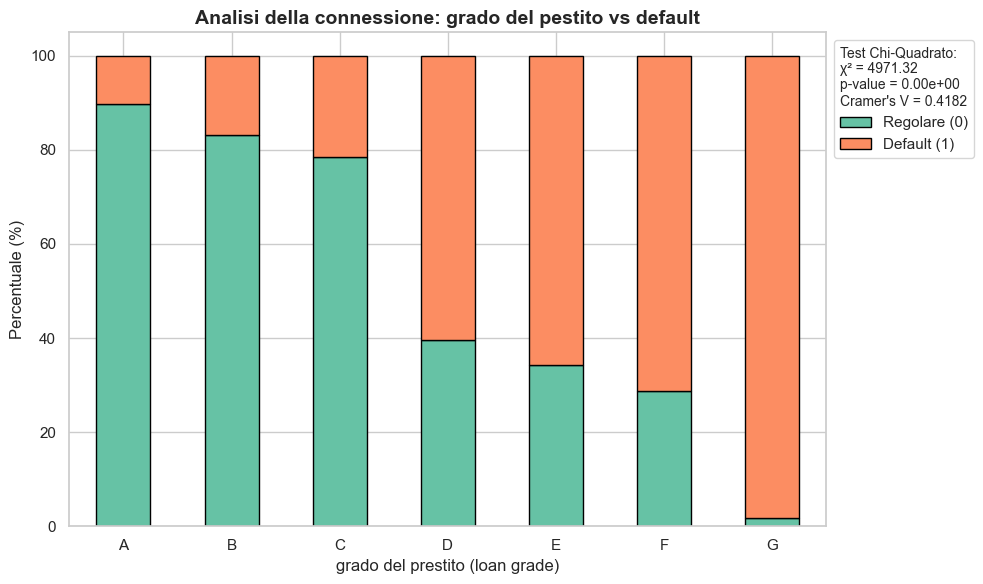

In [10]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np


tabella_contingenza = pd.crosstab(df_clean['loan_grade'], df_clean['loan_status'])


chi2, p, dof, expected = stats.chi2_contingency(tabella_contingenza)

n = tabella_contingenza.sum().sum()
min_dim = min(tabella_contingenza.shape) - 1
cramer_v = np.sqrt(chi2 / (n * min_dim))


tabella_perc = tabella_contingenza.div(tabella_contingenza.sum(1), axis=0) * 100

# 4. Creazione del 
fig, ax = plt.subplots(figsize=(10, 6))
tabella_perc.plot(kind='bar', stacked=True, color=['#66c2a5', '#fc8d62'], 
                  edgecolor='black', ax=ax)


stats_text = (f"Test Chi-Quadrato:\n"
              f"χ² = {chi2:.2f}\n"
              f"p-value = {p:.2e}\n"
              f"Cramer's V = {cramer_v:.4f}")


ax.legend(['Regolare (0)', 'Default (1)'], 
          title=stats_text, 
          title_fontsize=10, 
          loc='upper left', 
          bbox_to_anchor=(1, 1))


plt.title("Analisi della connessione: grado del pestito vs default", fontsize=14, fontweight='bold')
plt.xlabel("grado del prestito (loan grade)")
plt.ylabel("Percentuale (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

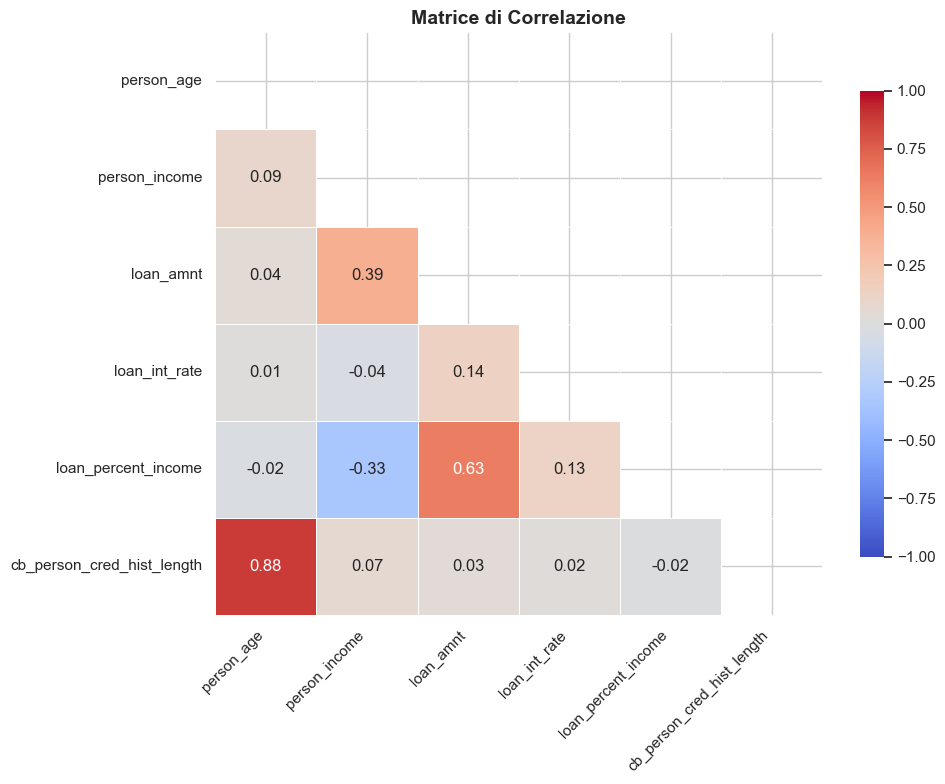

In [11]:


colonne_numeriche = ['person_age', 'person_income', 'loan_amnt', 
                     'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

matrice_correlazione = df_clean[colonne_numeriche].corr()

maschera = np.triu(np.ones_like(matrice_correlazione, dtype=bool))


plt.figure(figsize=(10, 8))
sns.heatmap(matrice_correlazione, mask=maschera, annot=True, fmt=".2f", 
            cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, 
            cbar_kws={"shrink": .8})

plt.title("Matrice di Correlazione", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\AndreaRiccobene\AppData\Local\Temp\ipykernel_24556\448308481.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlazione_target.values, y=correlazione_target.index, palette=colori)


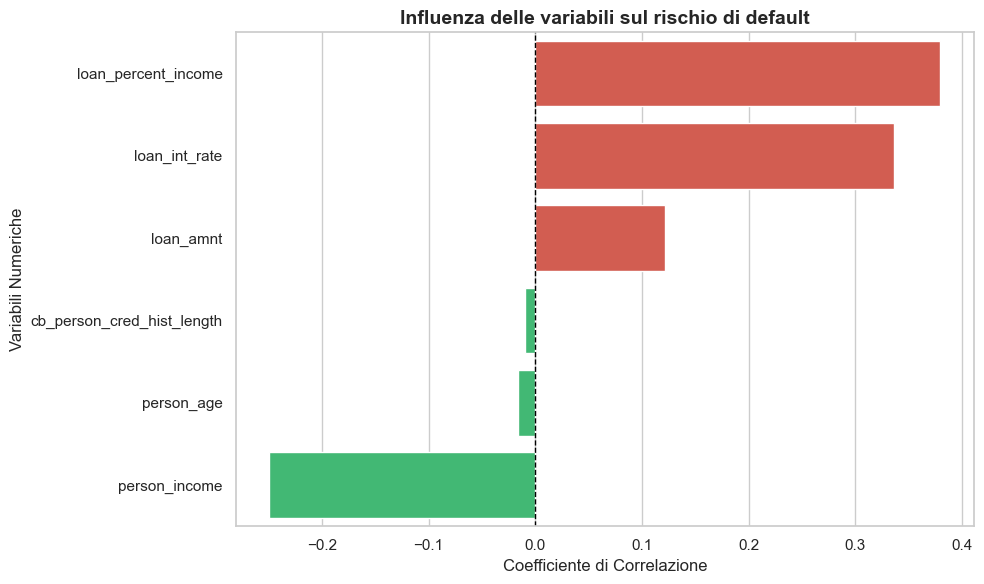

In [12]:

colonne = ['person_age', 'person_income', 'loan_amnt', 
           'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_status']

correlazione_target = df_clean[colonne].corr()['loan_status'].drop('loan_status')


correlazione_target = correlazione_target.sort_values(ascending=False)


plt.figure(figsize=(10, 6))

colori = ['#e74c3c' if x > 0 else '#2ecc71' for x in correlazione_target.values]

sns.barplot(x=correlazione_target.values, y=correlazione_target.index, palette=colori)

plt.title("Influenza delle variabili sul rischio di default", fontsize=14, fontweight='bold')
plt.xlabel("Coefficiente di Correlazione", fontsize=12)
plt.ylabel("Variabili Numeriche", fontsize=12)


plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

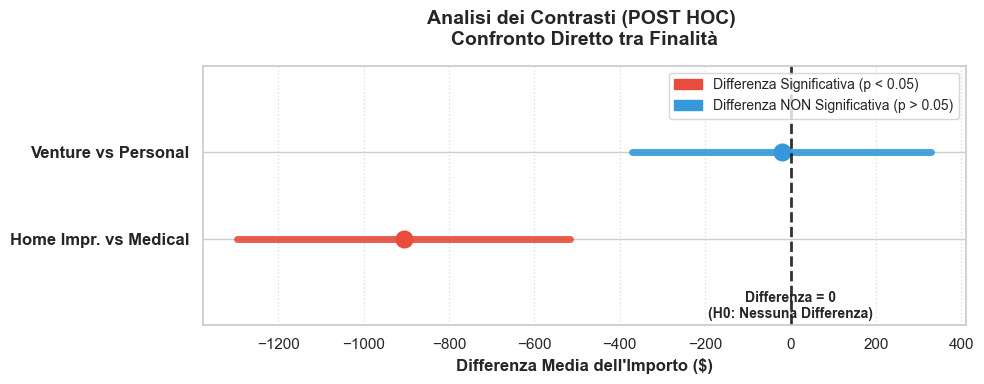

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.patches as mpatches

tukey_results = pairwise_tukeyhsd(endog=df_clean['loan_amnt'], 
                                  groups=df_clean['loan_intent'], 
                                  alpha=0.05)

tukey_df = pd.DataFrame(data=tukey_results._results_table.data[1:], 
                        columns=tukey_results._results_table.data[0])

tukey_df['pair'] = (tukey_df['group1'] + " vs " + tukey_df['group2']).str.upper()


condizione_1 = tukey_df['pair'].str.contains('HOME') & tukey_df['pair'].str.contains('MEDICAL')
condizione_2 = tukey_df['pair'].str.contains('VENTURE') & tukey_df['pair'].str.contains('PERSONAL')


df_filtrato = tukey_df[condizione_1 | condizione_2].reset_index(drop=True)


fig, ax = plt.subplots(figsize=(10, 4))

for i, row in df_filtrato.iterrows():
    pair_name = row['pair']
    

    if 'HOME' in pair_name:
        color = '#e74c3c'  
        label_text = 'Significativo (H0 Rifiutata)'
    else:
        color = '#3498db'  #
        label_text = 'NON Significativo (H0 Accettata)'
        

    ax.plot([row['lower'], row['upper']], [i, i], color=color, linewidth=5, alpha=0.9)

    ax.plot(row['meandiff'], i, 'o', color=color, markersize=12)


ax.axvline(0, color='black', linestyle='--', linewidth=2, alpha=0.8)
ax.text(0, -0.6, "Differenza = 0\n(H0: Nessuna Differenza)", ha='center', va='top', fontsize=10, fontweight='bold')


etichette_pulite = ["Venture vs Personal" if "VENTURE" in x else "Home Impr. vs Medical" for x in df_filtrato['pair']]

ax.set_yticks(range(len(df_filtrato)))
ax.set_yticklabels(etichette_pulite, fontsize=12, fontweight='bold')
ax.set_xlabel("Differenza Media dell'Importo ($)", fontsize=12, fontweight='bold')
ax.set_title("Analisi dei Contrasti (POST HOC) \nConfronto Diretto tra Finalità", fontsize=14, fontweight='bold', pad=15)


ax.set_ylim(-1, 2)

red_patch = mpatches.Patch(color='#e74c3c', label='Differenza Significativa (p < 0.05)')
blue_patch = mpatches.Patch(color='#3498db', label='Differenza NON Significativa (p > 0.05)')
ax.legend(handles=[red_patch, blue_patch], loc='upper right', fontsize=10)

plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()